# **과제3 이변량분석(y-범주) : 직원 이직 분석**


![](https://www.talentalign.com/wp-content/uploads/2019/09/main-qimg-2434943004743f79c0abf540cb4f6e2c-cropped.jpg)

* 직원 이직 분석
    * 회사에서 최근 1~2년 사이 이직률이 상승하였습니다.
    * 여러분은, 직원들이 이직하는데 중요한 요인이 무엇인지 데이터를 기반으로 한 분석을 의뢰 받았습니다.

## **1.환경준비**

* 라이브러리 불러오기

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic      #mosaic plot!

import scipy.stats as spst

* 데이터 불러오기 : 다음의 예제 데이터를 사용합니다.

In [4]:
# 직원 이직 데이터
path = 'https://raw.githubusercontent.com/DA4BAM/dataset/master/Attrition_simple3.csv'
data = pd.read_csv(path)
data.head(5)

,Attrition,Age,DistanceFromHome,EmployeeNumber,Gender,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,TotalWorkingYears
0,0,27,2,1898,Female,3,Single,6500,No,14,9
1,0,27,9,1965,Male,4,Single,4105,No,14,7
2,0,44,2,1703,Female,4,Married,7879,Yes,19,9
3,0,42,2,1231,Male,1,Married,6272,No,16,10
4,0,32,1,2016,Female,4,Married,10422,No,19,14


> * 변수설명
    * **Attrition**	:	이직여부, Yes , No (**Target**)
    * **Age**	:	나이
    * **DistanceFromHome**	:	집-직장 거리(마일)
    * **EmployeeNumber**	:	사번
    * **Gender**	:	성별(Male, Female)
    * **JobSatisfaction**	:	직무 만족도, 다음시트 참조
    * **MaritalStatus**	:	결혼상태(Married, Single, Divorced)
    * **MonthlyIncome**	:	월급(달러)
    * **OverTime**	:	야근여부
    * **PercentSalaryHike**	:	전년대비 급여인상율(%)
    * **TotalWorkingYears**	:	총 근무 연수



## **2.범주-->범주**

In [5]:
target = 'Attrition'

### **(1) Gender --> Attrition**

In [20]:
# 성별에 따른 이직여부의 관계
# 가설 : 이직여부와 성별은 관계가 크게 없을 것이다.


* 교차표

In [6]:
pd.crosstab(data['Gender'], data['Attrition'])

Attrition,0,1
Gender,,
Female,157,66
Male,248,129


* 시각화

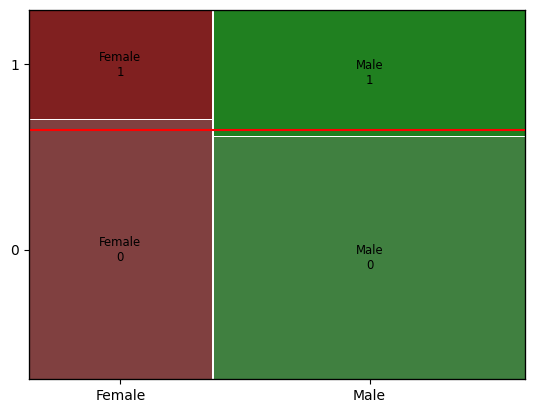

In [7]:
mosaic(data, [ 'Gender','Attrition'])
plt.axhline(1- data['Attrition'].mean(), color = 'r')

* 수치화 : 카이제곱검정

In [8]:
# Gender와 Attrition의 관계도
table = pd.crosstab(data['Gender'], data['Attrition'])
print(table)
print('---------------------------------------')

# 카이제곱 검정
chi2, p_value, dof, expected = spst.chi2_contingency(table)

print(f'카이제곱 통계량: {chi2:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'자유도: {dof}')
print('기대 빈도:')
print(expected)

if p_value < 0.05:
    print('유의수준 0.05에서 귀무가설(Gender와 Attrition은 독립이다)을 기각한다.')
else:
    print('유의수준 0.05에서 귀무가설(Gender와 Attrition은 독립이다)을 기각할 수 없습니다.')

Attrition    0    1
Gender             
Female     157   66
Male       248  129
---------------------------------------
카이제곱 통계량: 1.1614
p-value: 0.2812
자유도: 1
기대 빈도:
[[150.525  72.475]
 [254.475 122.525]]
유의수준 0.05에서 귀무가설(Gender와 Attrition은 독립이다)을 기각할 수 없습니다.


* 파악된 내용을 기술해 봅시다.

In [9]:
# 시각화를 통해 남성의 이직률이 여성에 비해 약간 높게 나온다는 것을 알 수 있다.
# 하지만 카이제곱 통계량에서 p-value는 유의수준이 0.05보다 크기 때문에 귀무가설(Gender와 Attrition은 독립이다)을 기각할 수 없다.
# 따라서 Gender와 Attrition은 연관성이 있다고 보기 어렵다.

# 이직과 성별은 크게 관련이 없으므로, 이직을 감소시키고자 할 때 크게 고려해야할 사항이 아니다.

### **(2) JobSatisfaction --> Attrition**

In [10]:
# 직업 만족도에 따른 이직여부의 관계
# 가설 : 직업 만족도와 이직여부은 관계가 있을 것이다.

* 교차표

In [11]:
pd.crosstab(data['JobSatisfaction'], data['Attrition'])

Attrition,0,1
JobSatisfaction,,
1,74,52
2,79,37
3,114,59
4,138,47


* 시각화

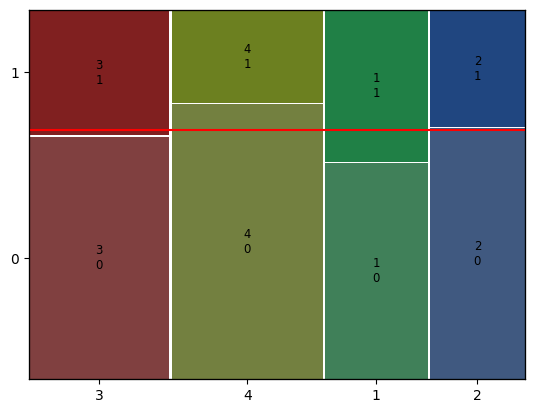

In [12]:
mosaic(data, ['JobSatisfaction','Attrition'])
plt.axhline(1- data['Attrition'].mean(), color = 'r')

* 수치화 : 카이제곱검정

In [13]:
# JobSatisfaction와 Attrition의 관계도
table = pd.crosstab(data['JobSatisfaction'], data['Attrition'])
print(table)
print('---------------------------------------')

# 카이제곱 검정
chi2, p_value, dof, expected = spst.chi2_contingency(table)

print(f'카이제곱 통계량: {chi2:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'자유도: {dof}')
print('기대 빈도:')
print(expected)

if p_value < 0.05:
    print('유의수준 0.05에서 귀무가설(JobSatisfaction와 Attrition은 독립이다)을 기각한다.')
else:
    print('유의수준 0.05에서 귀무가설(JobSatisfaction와 Attrition은 독립이다)을 기각할 수 없습니다.')

Attrition          0   1
JobSatisfaction         
1                 74  52
2                 79  37
3                114  59
4                138  47
---------------------------------------
카이제곱 통계량: 8.8842
p-value: 0.0309
자유도: 3
기대 빈도:
[[ 85.05   40.95 ]
 [ 78.3    37.7  ]
 [116.775  56.225]
 [124.875  60.125]]
유의수준 0.05에서 귀무가설(JobSatisfaction와 Attrition은 독립이다)을 기각한다.


* 파악된 내용을 기술해 봅시다.

In [ ]:
# 시각화를 통해 직업 만족도가 높을 수록 이직률이 감소하는 경향을 보인다.
# 카이제곱 통계량에서 p-value는 유의수준이 0.05보다 작기 때문에 귀무가설(JobSatisfaction와 Attrition은 독립이다)을 기각한다.
# 따라서 JobSatisfaction와 Attrition은 유의미한 연관성이 있다고 볼 수 있다.

# 직원의 직무 만족도를 높일 경우 이직을 줄일 수 있다.

### **(3) MaritalStatus --> Attrition**

In [14]:
# 결혼여부에 따른 이직여부의 관계
# 가설 : 결혼여부와 이직여부는 관계가 있을 것이다.

* 교차표

In [15]:
pd.crosstab(data['MaritalStatus'], data['Attrition'])

Attrition,0,1
MaritalStatus,,
Divorced,89,23
Married,205,69
Single,111,103


* 시각화

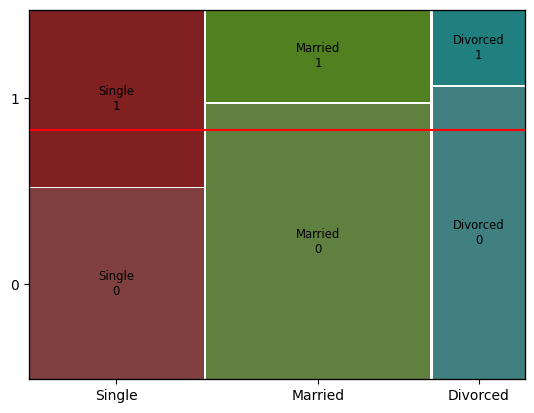

In [16]:
mosaic(data, ['MaritalStatus','Attrition'])
plt.axhline(1- data['Attrition'].mean(), color = 'r')

* 수치화 : 카이제곱검정

In [17]:
# MaritalStatus와 Attrition의 관계도
table = pd.crosstab(data['MaritalStatus'], data['Attrition'])
print(table)
print('---------------------------------------')


# 카이제곱 검정
chi2, p_value, dof, expected = spst.chi2_contingency(table)

print(f'카이제곱 통계량: {chi2:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'자유도: {dof}')
print('기대 빈도:')
print(expected)

if p_value < 0.05:
    print('유의수준 0.05에서 귀무가설(MaritalStatus와 Attrition은 독립이다)을 기각한다.')
else :
    print('유의수준 0.05에서 귀무가설(MaritalStatus와 Attrition은 독립이다)을 기각할 수 없습니다.')

Attrition        0    1
MaritalStatus          
Divorced        89   23
Married        205   69
Single         111  103
---------------------------------------
카이제곱 통계량: 37.8297
p-value: 0.0000
자유도: 2
기대 빈도:
[[ 75.6   36.4 ]
 [184.95  89.05]
 [144.45  69.55]]
유의수준 0.05에서 귀무가설(MaritalStatus와 Attrition은 독립이다)을 기각한다.


* 파악된 내용을 기술해 봅시다.

In [18]:
# 시각화를 통해 미혼자는 기혼자와 이혼한 사람에 비해 이직률이 높게 나타나는 경향을 보인다.
# 카이제곱 통계량에서 p-value는 유의수준이 0.05보다 작기 때문에 귀무가설(MaritalStatus와 Attrition은 독립이다)을 기각한다.
# 따라서 MaritalStatus와 Attrition은 유의미한 연관성이 있다고 볼 수 있다.

# 직원의 결혼을 장려할 경우 이직을 줄일 수 있다.

### **(4) OverTime --> Attrition**

In [19]:
# 야근여부에 따른 이직여부의 관계
# 가설 : 야근여부와 이직여부는 관계가 있을 것이다.

* 교차표

In [20]:
pd.crosstab(data['OverTime'], data['Attrition'])

Attrition,0,1
OverTime,,
No,315,90
Yes,90,105


* 시각화

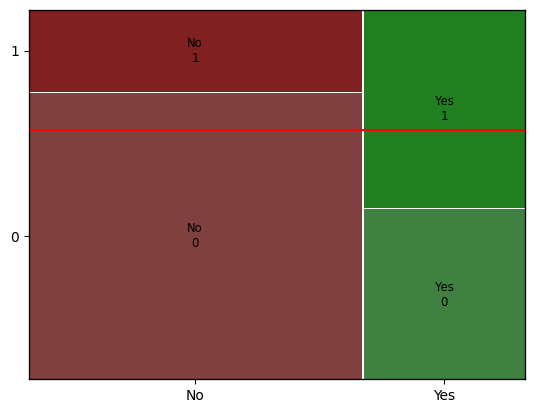

In [21]:
mosaic(data, ['OverTime','Attrition'])
plt.axhline(1- data['Attrition'].mean(), color = 'r')

* 수치화 : 카이제곱검정

In [22]:
# OverTime와 Attrition의 관계도
table = pd.crosstab(data['OverTime'], data['Attrition'])
print(table)
print('---------------------------------------')


# 카이제곱 검정
chi2, p_value, dof, expected = spst.chi2_contingency(table)

print(f'카이제곱 통계량: {chi2:.4f}')
print(f'p-value: {p_value:.4f}')
print(f'자유도: {dof}')
print('기대 빈도:')
print(expected)

if p_value < 0.05:
    print('유의수준 0.05에서 귀무가설(OverTime와 Attrition은 독립이다)을 기각한다.')
else :
    print('유의수준 0.05에서 귀무가설(OverTime와 Attrition은 독립이다)을 기각할 수 없습니다.')

Attrition    0    1
OverTime           
No         315   90
Yes         90  105
---------------------------------------
카이제곱 통계량: 58.5715
p-value: 0.0000
자유도: 1
기대 빈도:
[[273.375 131.625]
 [131.625  63.375]]
유의수준 0.05에서 귀무가설(OverTime와 Attrition은 독립이다)을 기각한다.


* 파악된 내용을 기술해 봅시다.

In [ ]:
# 시각화를 통해 야근이 있는 사람들이 이직이 높게 나타나는 경향을 보인다.
# 카이제곱 통계량에서 p-value는 유의수준이 0.05보다 작기 때문에 귀무가설(OverTime와 Attrition은 독립이다)을 기각한다.
# 따라서 OverTime와 Attrition은 유의미한 연관성이 있다고 볼 수 있다.

# 야근을 줄이면 직원의 이직을 감소시킬 수 있다.

## **3.숫자-->범주**

### **(1) Age --> Attrition**

In [ ]:
# 나이에 따른 이직여부의 관계
# 가설 : 나이와 이직여부는 관계가 있을 것이다.

* 시각화

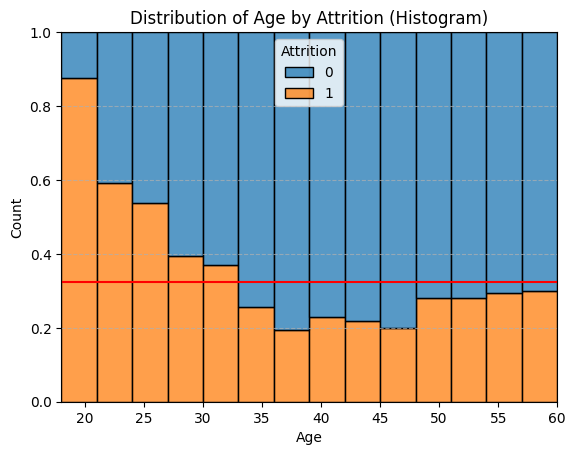

In [23]:
# 히스토그램
sns.histplot(data=data, x='Age', hue='Attrition', multiple='fill')
plt.title('Distribution of Age by Attrition (Histogram)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(data['Attrition'].mean(), color = 'r')

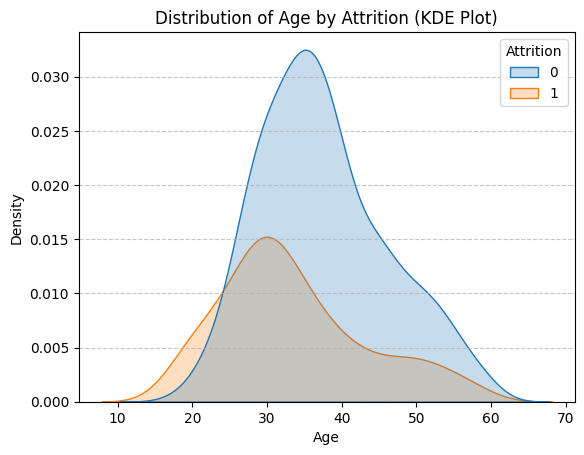

In [24]:
# KDE 연결선
sns.kdeplot(data=data, x='Age', hue='Attrition',  fill=True)
plt.title('Distribution of Age by Attrition (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)

* 파악된 내용을 기술해 봅시다.

In [ ]:
# 히스토그램을 통해 나이가 젊을 수록 이직하려는 경향이 높기 나타난다. 반대로 나이가 많아질수록 이직 경향이 줄어든다.
# KDE를 통해 전체적으로 이직하려는 사람에 20후반에서 30초 중반이 가장 높게 나타나고, 이직을 하지 않은 사람들은 30후반에서 40초반이 높게 나타난 것을 알 수 있다.
# 이를 통해 나이에 따른 이직여부는 관계가 있다는 것을 알 수 있고, 젊은 사람일 수록 이직의 경향이 높게 나타난다.

### **(2) DistanceFromHome --> Attrition**

In [ ]:
# 통근거리에 따른 이직여부의 관계
# 가설 : 통근거리와 이직여부는 관계가 있을 것이다.

* 시각화

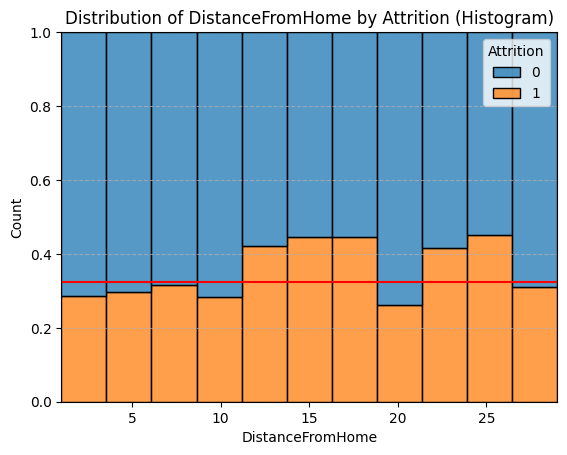

In [25]:
# 히스토그램
sns.histplot(data=data, x='DistanceFromHome', hue='Attrition', multiple='fill')
plt.title('Distribution of DistanceFromHome by Attrition (Histogram)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(data['Attrition'].mean(), color = 'r')

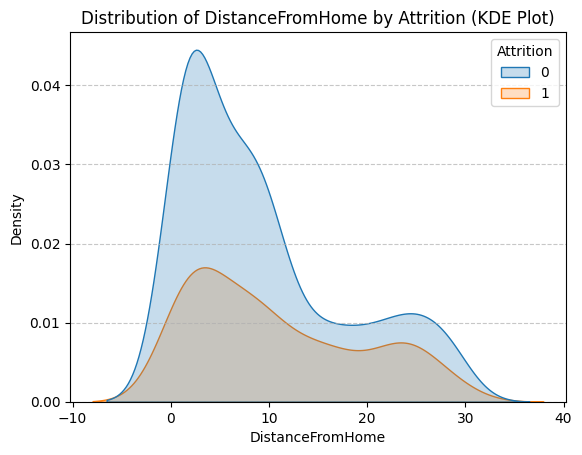

In [26]:
# KDE 연결선
sns.kdeplot(data=data, x='DistanceFromHome', hue='Attrition',  fill=True)
plt.title('Distribution of DistanceFromHome by Attrition (KDE Plot)')
plt.xlabel('DistanceFromHome')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)

* 파악된 내용을 기술해 봅시다.

In [27]:
# 히스토그램을 통해 통근거리가 긴 사람일 수록 이직하는 경향이 높게 나타난다.
# 하지만 KDE를 통해 전체적으로 이직하려는 사람과 그렇지 않은 사람 모두 통근 거리가 0~10m 사이에서 밀도가 높다는 것을 알 수 있다.
# 이를 통해 통근 거리에 따른 이직여부는 관계가 있다고 보기 어렵다.

### **(3) MonthlyIncome --> Attrition**

In [28]:
# 월급에 따른 이직여부의 관계
# 가설 : 월급 이직여부는 관계가 있을 것이다.

* 시각화

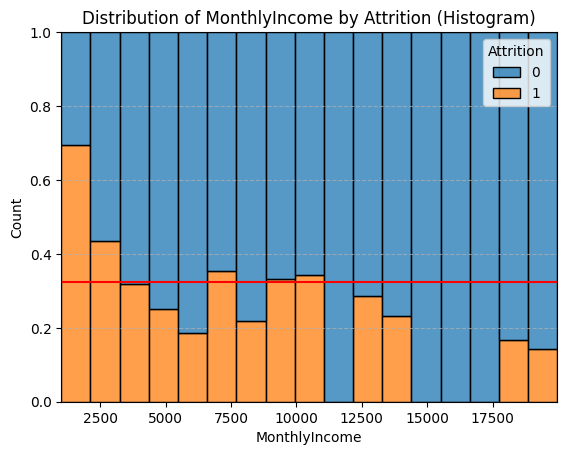

In [29]:
# 히스토그램
sns.histplot(data=data, x='MonthlyIncome', hue='Attrition', multiple='fill')
plt.title('Distribution of MonthlyIncome by Attrition (Histogram)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(data['Attrition'].mean(), color = 'r')

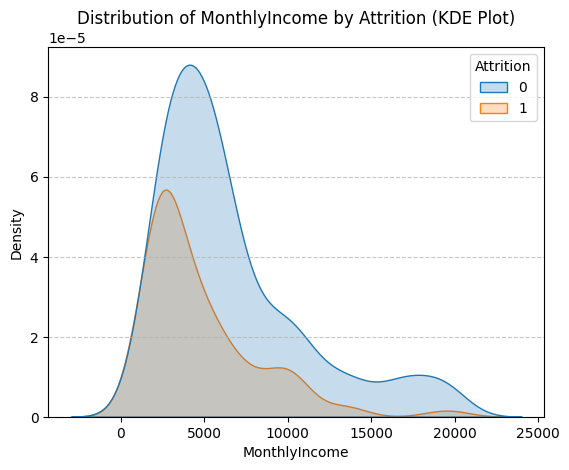

In [30]:
# KDE 연결선
sns.kdeplot(data=data, x='MonthlyIncome', hue='Attrition',  fill=True)
plt.title('Distribution of MonthlyIncome by Attrition (KDE Plot)')
plt.xlabel('MonthlyIncome')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)

* 파악된 내용을 기술해 봅시다.

In [ ]:
# 히스토그램을 통해 월급이 적은 사람일 수록 높은 사람들에 비해 이직하는 경향이 높게 나타난다.
# 또한 KDE를 통해 전체적으로 이직하려는 사람과 그렇지 않은 사람 모두 2500정도에서 밀도가 높다는 것을 알 수 있다.
# 이를 통해 월급에 따른 이직여부는 관계가 있다고 볼 수 있다.

# 또한 월급이 5000이상으로 올라갈 경우 이직하는 정도가 크게 급감하는 것으로 보아, 5000이상의 월급에 직원이 만족한다는 것을 알 수 잇다.

### **(4) PercentSalaryHike --> Attrition**

In [ ]:
# 급여 인상률에 따른 이직여부의 관계
# 가설 : 급여 인상률과 이직여부는 관계가 있을 것이다.

* 시각화

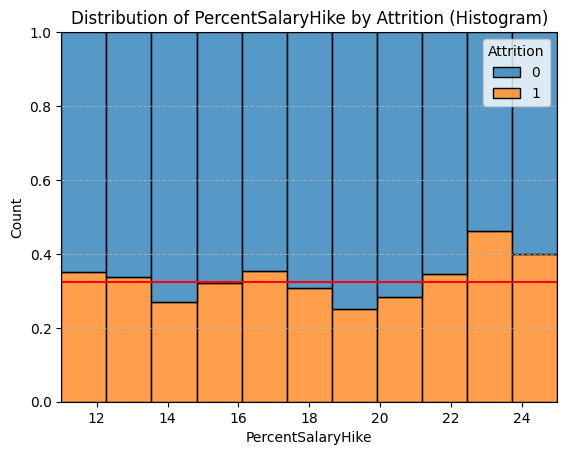

In [31]:
# 히스토그램
sns.histplot(data=data, x='PercentSalaryHike', hue='Attrition', multiple='fill')
plt.title('Distribution of PercentSalaryHike by Attrition (Histogram)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(data['Attrition'].mean(), color = 'r')

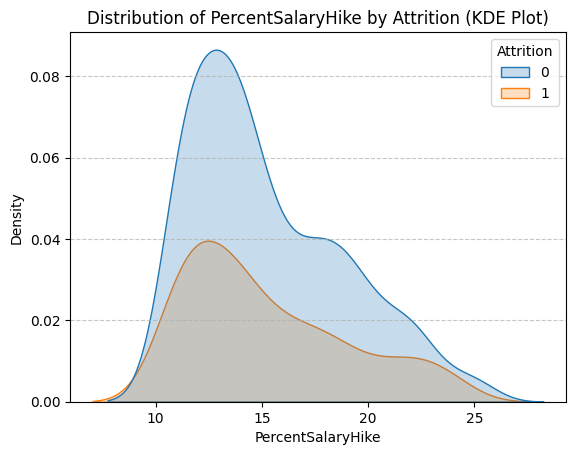

In [32]:
# KDE 연결선
sns.kdeplot(data=data, x='PercentSalaryHike', hue='Attrition',  fill=True)
plt.title('Distribution of PercentSalaryHike by Attrition (KDE Plot)')
plt.xlabel('PercentSalaryHike')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)

* 파악된 내용을 기술해 봅시다.

In [ ]:
# 히스토그램을 통해 월급의 인상이 적은 쪽과 중간, 그리고 많은 쪽 모두에서 다양하게 높은 이직정도를 보인다.
# 또한 KDE를 통해 전체적으로 이직하려는 사람과 그렇지 않은 사람 모두 12~15% 인상정도에서 밀도가 높다는 것을 알 수 있다.
# 이를 통해 월급 인상률에 따른 이직여부는 관계가 있다고 보기 어렵다.

### **(5) TotalWorkingYears --> Attrition**

In [ ]:
# 종합 근무 연수에 따른 이직여부의 관계
# 가설 : 총 근무 연수와 이직여부는 관계가 있을 것이다.

* 시각화

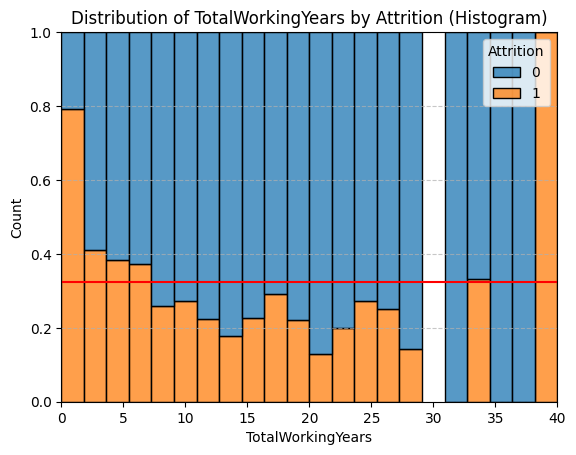

In [33]:
# 히스토그램
sns.histplot(data=data, x='TotalWorkingYears', hue='Attrition', multiple='fill')
plt.title('Distribution of TotalWorkingYears by Attrition (Histogram)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(data['Attrition'].mean(), color = 'r')

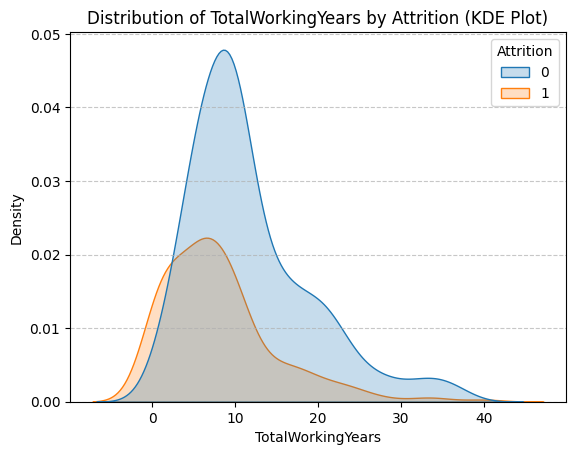

In [34]:
# KDE 연결선
sns.kdeplot(data=data, x='TotalWorkingYears', hue='Attrition',  fill=True)
plt.title('Distribution of TotalWorkingYears by Attrition (KDE Plot)')
plt.xlabel('TotalWorkingYears')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)

* 파악된 내용을 기술해 봅시다.

In [ ]:
# 히스토그램을 통해 총 근무 연수가 적은 사람과 많은 사람들 모두에서 이직하려는 경향이 높게 나타난다.
# 또한 KDE를 통해 전체적으로 이직하려는 사람과 그렇지 않은 사람 모두 7~8년 정도에서 밀도가 높다는 것을 알 수 있다.
# 이를 통해 총 근무 연수에 따른 이직여부는 관계가 있다고 볼 수 있다.

# 또한 총 근무 연수가 10년을 넘어갈 경우 이직하는 정도가 크게 급감하는 것으로 보아, 10년이상의 근무 연수를 채워 주는 것이 이직률을 감소 시킬 수 있을 것이다.

## **4.관계 정리하기**
* 각 변수(feature)에 대해서 이직여부와의 관계를 정리해 봅시다.(주관적으로)

① 강한관계

In [ ]:
# '범주 -> 범주'에서의 강한 관계
# 1. JobSatisfaction --> Attrition
# 2. MaritalStatus --> Attrition
# 3. OverTime --> Attrition
# 이유 : 해당 직업 만족도, 결혼 여부, 초과근무 여부 등은 모두 p-value가 유의수준이 0.05보다 작은 값으로 나타났으므로, 모두 강한 상관관계를 지닌다는 것을 알 수 있다.

# '숫자 -> 범주'에서의 강한 관계
# 1. Age --> Attrition
# 2. MonthlyIncome --> Attrition
# 3. TotalWorkingYears --> Attrition
# 이유1 : 나이가 적을 수록, 이직하려는 경향이 높게 나타나고, 반대로 많을 수록, 이직 경향이 적게나타난다.
# 이유2 : 또한, 월급이 0~2500정도에서 높은 이직여부를 보이고, 이후 5000이 넘어가는 순간 이직하려는 정도가 급감한다는 것을 알 수 있다.
# 이유3 : 근무 연수가 많을 수록, 이직여부가 줄어든다. 특히, 총 근무 10년을 넘어가기 이전에 이직 정도가 되다가, 10년 이후로 급격히 줄어들기 때문에 강한 상관관계를 가진다는 것을 볼 수 잇다.

② 중간관계

In [ ]:
# '범주 -> 범주'에서의 중간 관계
# 없다.

# '숫자 -> 범주'에서의 중간 관계
# 1. PercentSalaryHike --> Attrition
# 이유1 : 임금 인상률이 적을 수록 이직여부가 높게 나타나지만, 이직 인상률이 가장 높을 때, 이직정도가 가장 높게 나타나므로, 상관관계가 강한다고 볼 수 는 없다.

③ 관계없음(약한 관계)

In [ ]:
# '범주 -> 범주'에서의 약한 관계
# 1. Gender --> Attrition
# 이유 : 해당 성별은 p-value가 유의수준이 0.05보다 큰 값으로 나타났으므로, 이직 여부와 상관관계가 매우 적다는 것을 알 수 있다..

# '숫자 -> 범주'에서의 약한 관계
# 1. DistanceFromHome --> Attrition
# 이유 : 거리에 따른 이직여부가 가까울 수록 줄어들지만, 반대로 늘어났음에도, 이직 여부가 줄어든 다는 것을 알 수 있다. 이로 인해, 둘의 상관관계가 약하다고 볼 수 있다.